# *Advanced SixGman Scenarios*

In [1]:
# Import Dependencies
import sys
from pathlib import Path
import os
import numpy as np
import pandas as pd
import json

# Ignore warnings to have clean cell outputs
import warnings
warnings.filterwarnings("ignore")

### *Create results directory if it doesn't exist*

In [2]:
# Get the current working directory (where the notebook is running)
base_dir = Path.cwd()

# Define the results directory
results_dir = base_dir.parent / "results" / "50G_Complete"

# Create it if it doesn't exist
results_dir.mkdir(exist_ok=True)

print(f"Results will be saved in: {results_dir}")

Results will be saved in: /media/matin/DataDisk/University/Master/Project/Codes/SixDman_GitHub_Repo/SixDman/results/50G_Complete


In [3]:
sys.path.append(os.path.abspath(base_dir.parent / 'src'))
from sixgman.core.network import Network
from sixgman.core.band import Band, OpticalParameters
from sixgman.core.planning import PlanningTool
from sixgman.core.post_process import analyse_result

### *1. Create Network Instance*

In [4]:
# Initialize network
network = Network(topology_name = 'MAN157')

# Load topology from .mat file
network.load_topology(filepath = '../data/MAN157Nodes.mat', matrixName ='MAN157Nodes')

# Set hierarchical levels
hl_dict = network.define_hierarchy(
    HL1_standalone = [1, 5],
    HL2_standalone = [0, 2, 3, 4],
    HL3_standalone = list(range(6, 39)),
    HL4_standalone = list(range(39, 157))
)

### 2. *Define hierarchy node levels*

In [5]:
HL4_Standalone = hl_dict['HL4']['standalone']
HL4_colocated = hl_dict['HL4']['colocated']

HL3_Standalone = hl_dict['HL3']['standalone']
HL3_colocated = hl_dict['HL3']['colocated']

HL2_Standalone = hl_dict['HL2']['standalone']
HL2_colocated = hl_dict['HL2']['colocated']

HL1_Standalone = hl_dict['HL1']['standalone']

HL123_Standalone = HL1_Standalone + HL2_Standalone + HL3_Standalone
HL12_Standalone = HL1_Standalone + HL2_Standalone

arr = np.arange(network.adjacency_matrix.shape[0]) 
exclude_list = HL2_Standalone + HL3_Standalone + HL4_Standalone + HL1_Standalone
Optical_Nodes = arr[~np.isin(arr, exclude_list)]


### *3. Define Transmission Bands*

In [6]:
# Define C-band parameters
c_band_params = OpticalParameters(Rs_mat = 40e9)

# Create C-band instance
c_band = Band(
    name='C',
    start_freq = 190.65, # THz
    end_freq = 196.675, # THz
    opt_params = c_band_params,
    network_instance = network,
    channel_spacing = 0.05 # THz
    )

# Define L-band parameters
l_band_params = OpticalParameters(Rs_mat = 40e9)

# Create L-band instance
l_band = Band(
    name='L',
    start_freq = 184.525, # THz
    end_freq = 190.565, # THz
    opt_params = l_band_params,
    network_instance = network,
    channel_spacing = 0.05 # THz
)

In [7]:
# define C-band and L-band frequency slots
spectrum_C = c_band.calc_spectrum()
spectrum_L = l_band.calc_spectrum()

# concatenate C-band and KL-band to a sigle frequency spectrum
spectrum = np.concatenate((spectrum_C, spectrum_L))

f_c_axis = spectrum * 1e12  # Convert to Hz
Pch_dBm = np.arange(-6, -0.9, 0.1)  # Channel power in dBm
num_Ch_mat = np.arange(1, len(spectrum) - 1)  # Channel indices

# define total number of frequency slots
num_fslots = len(num_Ch_mat)

In [8]:
C_band_num_channels = int(4800 / 50)
supC_band_num_channels = int(1200 / 50)
L_band_num_channels = int(6000 / 50)

### *4. Create Planning Tool and Optimize Network*

In [9]:
# Initialize planning tool
planner = PlanningTool(
    network_instance = network,
    bands = [c_band, l_band], # simulate network over C and L Band
    optical_parameters = c_band_params,
    grid_center = f_c_axis, 
    period_time = 10) # simulate network for 10 years

all_node_degree = network.get_node_degrees(np.arange(network.adjacency_matrix.shape[0]))[:, 1]

#### *4.1 Define number of hierarchical levels*

In [10]:
num_level_process = 4
minimum_hierarchy_level = 4
processing_level_list = [4, 3, 2]
splitter = []

### *5. Simulate network level by level*

In [11]:
# Iterate through each hierarchical levels
for hierarchy_level in processing_level_list:

    print(f"Processing hierarchy level: {hierarchy_level}")

    # Define some variables based on each hierarchical level
    match hierarchy_level:

        case 2:
            HL_Standalone = HL2_Standalone
            HL_colocated = HL2_colocated
            HL_lower_Standalone = HL4_Standalone + HL3_Standalone
            HL_up_Standalone = HL1_Standalone
            HL_all = np.concatenate((HL2_Standalone, HL2_colocated))
            capacity_updt_index = 0
            prev_hierarchy_level = 3
        case 3:
            HL_Standalone = HL3_Standalone
            HL_colocated = HL3_colocated
            HL_lower_Standalone = HL4_Standalone
            HL_up_Standalone = HL12_Standalone
            HL_all = np.concatenate((HL3_Standalone, HL3_colocated))
            capacity_updt_index = 1
            prev_hierarchy_level = 4
        case 4:
            HL_Standalone = HL4_Standalone
            HL_colocated = HL4_colocated
            HL_lower_Standalone = []
            HL_up_Standalone = HL123_Standalone
            HL_all = np.concatenate((HL4_Standalone, HL4_colocated))
            capacity_updt_index = 2
            prev_hierarchy_level = None

    # Calculate subnet matrix of this hierarchical level
    sub_graph_HL, subnetMatrix_HL = network.compute_hierarchy_subgraph(hierarchy_level, minimum_hierarchy_level)

    # Calculate connected nodes to standalone HL (candidate destinations)
    HL_connected_nodes = network.get_neighbor_nodes(HL_Standalone) - set(HL_lower_Standalone)
    splitter.append(len(list(sub_graph_HL.edges())))

    ### Calculate candidate paths for standalone HLs

    # Define CSV file_name for candidate paths for standalone HL nodes
    file_name = results_dir/  f"{network.topology_name}_HL{hierarchy_level}_K_path_attributes.csv"

    # Check if the CSV file exists
    if file_name.exists():

        # If the file exists -> load the CSV file containing candidate paths for standalone HL nodes
        print(f"Loading K-path attributes of HL{hierarchy_level} ...")

        K_path_attributes_df = pd.read_csv(file_name)
        K_path_attributes_df['links'] = K_path_attributes_df['links'].map(json.loads)
        K_path_attributes_df['nodes'] = K_path_attributes_df['nodes'].map(json.loads)

    else:
        # If the file doesn't exist -> calculate candidate paths 

        print(f"Calculating K-path attributes of HL{hierarchy_level} ...")

        # Define number of candidate paths per node
        k_paths = 20

        # Define a variable to store the HL nodes that doesn't have any LAND pair with this k_paths
        source_not_found = HL_Standalone.copy()

        # Continue calculating candiate paths till all the HL nodes have at least one LAND pair
        while len(source_not_found) != 0:

            # define a list to store path attributes for this iteration
            K_path_attributes = []

            # iterate through each "source_not_found" node only
            for src in HL_Standalone:
                for dest in HL_connected_nodes:
                    # Calculate k_paths candidate paths for (src, dest) pair
                    K_path_attributes = network.compute_k_shortest_paths(subnetMatrix_HL, K_path_attributes, source = src, target = dest, k = k_paths)

            # Convert K_path_attributes list to a temporary DataFrame
            K_path_attributes_df = pd.DataFrame(K_path_attributes)

            # Optionally save to CSV (if you want to track progress)
            K_path_attributes_df.to_csv(file_name, index=False)

            # Sort candidate paths dataframe by num_hops and distance
            K_path_attributes_df_sorted = K_path_attributes_df.groupby(['src_node'], group_keys=False).apply(
                lambda x: x.sort_values(['num_hops', 'distance'])
            )

            # find disjoint pairs from the sorted full dataset
            pairs_disjoint = network.land_pair_finder(HL_Standalone, K_path_attributes_df_sorted, num_pairs = 1)

            # Update source_not_found to exclude newly matched source nodes
            source_not_found = np.setdiff1d(HL_Standalone, pairs_disjoint['src_node'].unique())
            
            # Print the Hl nodes that doesn't have LAND pair
            print(f"k_path = {k_paths}, Remaining src nodes: {source_not_found}")

            # Increase the k_paths value by 20 
            k_paths += 20
    
    ### Calculate candidate paths for colocated HLs

    # Define CSV file_name for candidate paths for colocated HL nodes
    file_name = results_dir/ f"{network.topology_name}_HL{hierarchy_level}_K_path_attributes_colocated.csv"

    # Check if the CSV file exists
    if file_name.exists():

        print(f"Loading K-path attributes of HL{hierarchy_level} colocated...")

        # If the file exists -> load the CSV file containing candidate paths for colocated HL nodes
        K_path_attributes_colocated_df = pd.read_csv(file_name)
        K_path_attributes_colocated_df['links'] = K_path_attributes_colocated_df['links'].map(json.loads)
        K_path_attributes_colocated_df['nodes'] = K_path_attributes_colocated_df['nodes'].map(json.loads)

    else:
        # If the file doesn't exist -> calculate candidate paths 

        print(f"Calculating K-path attributes of HL{hierarchy_level} colocated...")
        
        # Define number of candidate paths per node
        k_paths = 20

        # define a list to store path attributes
        K_path_attributes_colocated = []

        # iterate through each colocated HL node
        for src in HL_colocated:
            
            # In the third hierarchical level we can't have standalone HL1 destinations for standalone HL2s 
            if (hierarchy_level == 3) and (src in HL2_Standalone):
                HL_connected_nodes_col = HL_connected_nodes - set(HL1_Standalone)
            else:
                HL_connected_nodes_col = HL_connected_nodes.copy()

            for dest in HL_connected_nodes:
                if src != dest:
                    # Calculate k_paths candidate paths for (src, dest) pair
                    K_path_attributes_colocated = network.compute_k_shortest_paths(subnetMatrix_HL, K_path_attributes_colocated, source = src, target = dest, k = k_paths)

        # Convert K_path_attributes list to dataframe
        K_path_attributes_colocated_df = pd.DataFrame(K_path_attributes_colocated)

        # save dataframe to csv file
        K_path_attributes_colocated_df.to_csv(file_name, index = False)

    
    # sort dataframes based on num_hops and distance (in order)
    K_path_attributes_df_sorted = K_path_attributes_df.groupby(['src_node'], group_keys = False).apply(lambda x: x.sort_values(['num_hops', 'distance']))
    K_path_attributes_colocated_df_sorted = K_path_attributes_colocated_df.groupby(['src_node', 'dest_node'], group_keys = False).apply(lambda x: x.sort_values(['num_hops', 'distance']))

    # find disjoint pairs for HL standalone nodes
    pairs_disjoint = network.land_pair_finder(HL_Standalone, K_path_attributes_df_sorted, num_pairs = 1)

    ### Calculate HL links GSNR
    print(f"process link GSMR of HL{hierarchy_level} ...")

    # Note that if the GSNR values calculated before, the function load the precalculated file
    GSNR_opt_link, _, _, power_opt_link = c_band.process_link_gsnr(f_c_axis = f_c_axis, 
                                                                   Pch_dBm = Pch_dBm, 
                                                                   num_Ch_mat = num_Ch_mat,
                                                                   spectrum_C = spectrum_C,
                                                                   Nspan_array = np.ones(network.all_links.shape[0], dtype=int),
                                                                   hierarchy_level = hierarchy_level, 
                                                                   minimum_hierarchy_level = minimum_hierarchy_level, 
                                                                   result_directory = results_dir)
    
    ### Initialize planner
    planner.initialize_planner(num_fslots = num_fslots, 
                               hierarchy_level = hierarchy_level,
                               minimum_hierarchy_level = minimum_hierarchy_level, 
                               SR = 40 * 1e9, # Symbol rate of 50G channels (in Hz)
                               Max_bit_rate_BVT = np.array([400, 348, 280, 200, 120, 80]), # 400 Gbps BVTs
                               Ref_license_capacity = np.array([100, 87, 70, 50, 30, 20]), # reference license capacities corresponding to BVTs
                               FP_max_num = 20,
                               band_sepration_idx = [C_band_num_channels, 
                                                     C_band_num_channels + supC_band_num_channels])
    
    # Check for being in the minimum hierarchical level
    if hierarchy_level == minimum_hierarchy_level:

        # generate port capacity for minimum HL nodes uisng Monte Carlo simulation
        planner.generate_initial_traffic_profile(num_nodes = len(HL_all),
                                                 optical_nodes = Optical_Nodes, 
                                                 monteCarlo_steps = 100,
                                                 min_rate = 20, # Gbps
                                                 max_rate = 200, # Gbps
                                                 seed = 50, 
                                                 result_directory = results_dir)

        # Traffic growth simulation over 10 years
        planner.simulate_traffic_annual(lowest_hierarchy_dict = hl_dict[f"HL{hierarchy_level}"], 
                                        CAGR = 0.4, 
                                        result_directory = results_dir)
    
    ### Simulate network for this hierarchical level
    print(f"running planner for HL{hierarchy_level} ...")

    # run the planner for the current hierarchy level    
    planner.run_planner(hierarchy_level = hierarchy_level,
                        prev_hierarchy_level = prev_hierarchy_level,
                        pairs_disjoint = pairs_disjoint,
                        kpair_standalone = 1,
                        kpair_colocated = 1,
                        candidate_paths_standalone_df = K_path_attributes_df,
                        candidate_paths_colocated_df = K_path_attributes_colocated_df_sorted,
                        P_opt_links = power_opt_link,
                        GSNR_opt_link = GSNR_opt_link,
                        Nspan_array = np.ones(len(network.all_links), dtype = int),
                        all_node_degree = all_node_degree,
                        minimum_level = minimum_hierarchy_level,
                        node_cap_update_idx = capacity_updt_index, 
                        result_directory = results_dir)


Processing hierarchy level: 4
Loading K-path attributes of HL4 ...
Loading K-path attributes of HL4 colocated...
process link GSMR of HL4 ...
Loading precomputed link GSNR analysis
Loading precomputed HL_capacity_final ...
Loading precomputed Traffic Matrix ...
running planner for HL4 ...
Processing Year:  1
Processing standalone node 39
Processing standalone node 40
Processing standalone node 41
Processing standalone node 42
Processing standalone node 43
Processing standalone node 44
Processing standalone node 45
Processing standalone node 46
Processing standalone node 47
Processing standalone node 48
Processing standalone node 49
Processing standalone node 50
Processing standalone node 51
Processing standalone node 52
Processing standalone node 53
Processing standalone node 54
Processing standalone node 55
Processing standalone node 56
Processing standalone node 57
Processing standalone node 58
Processing standalone node 59
Processing standalone node 60
Processing standalone node 61


### *6. Plot the results*

#### *6.1 Link state profile*

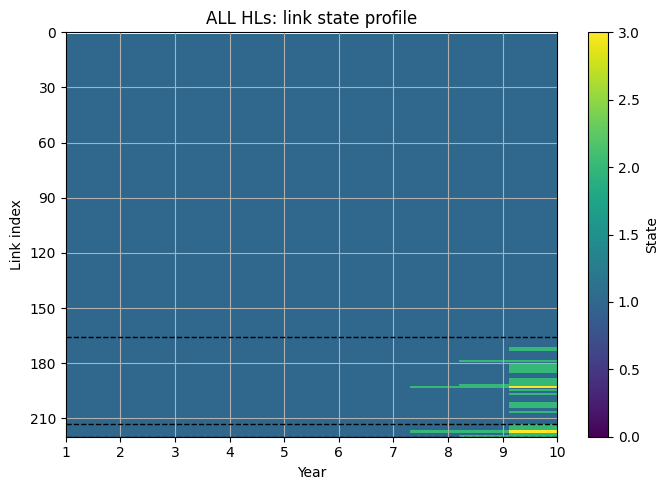

In [12]:
analysing = analyse_result(network, 10, processing_level_list, results_dir, save_directory = results_dir / 'plots')
analysing.plot_link_state(minimum_hierarchy_level = 4, 
                          splitter = splitter, 
                          save_flag = 0,
                          save_suffix = "_NoBypass")

#### *6.2 Fiber Pair Usage in km and number*

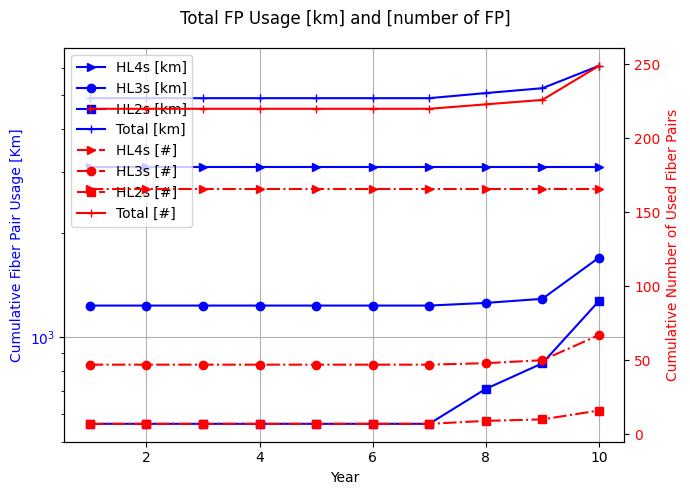

In [13]:
analysing.plot_FP_usage(save_flag = 0, 
                        save_suffix = "_NoBypass")

#### *6.3 Number of BVT and 100G licenses*

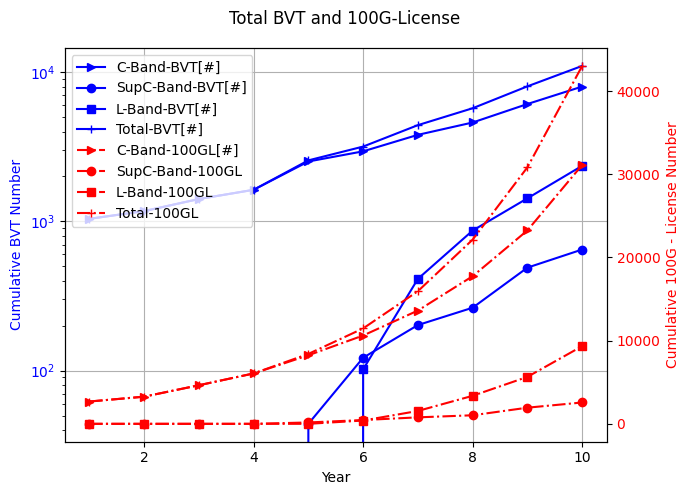

In [14]:
analysing.plot_bvt_license(save_flag = 0, 
                           save_suffix = "_NoBypass")

#### *6.4 Fiber Pair in km and different Band degress*

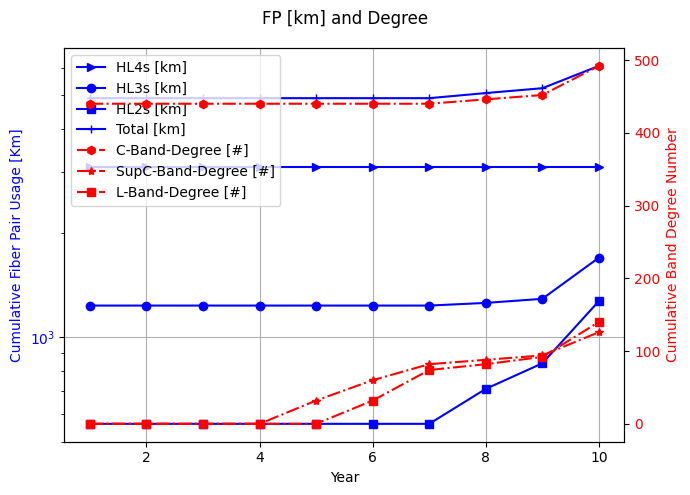

In [15]:
analysing.plot_FP_degree(save_flag = 0, 
                        save_suffix = "_NoBypass")

#### *6.5 Cost analysis*

In [16]:
analysing.calc_cost(save_flag = 0, 
                    save_suffix = "_NoBypass")

,OPEX,Capex_RoB,Capex_MCS,Capex_100GL,CAPEX
0,2450.22,836.000000,45.500000,1586.120000,2467.620000
1,2450.22,0.000000,5.775000,282.516000,288.291000
2,2450.22,0.000000,10.500000,616.956000,627.456000
3,2450.22,0.000000,9.450000,616.932000,626.382000
4,2450.22,3.590179,41.063669,1411.153754,1455.807603
5,2450.22,9.289589,27.255665,1455.027618,1491.572872
6,2450.22,9.632900,55.889784,2384.412737,2449.935421
7,2534.79,13.199353,59.409328,3026.099078,3098.707759
8,2617.77,13.313857,103.081422,4537.861141,4654.256421
9,3036.47,84.479860,133.453395,6186.246818,6404.180072


#### *6.6 Calculate Latency*

In [17]:
analysing.calc_E2E_latency_Total(planner.path_latency_storage, 
								planner.destinations_storage,
    							processing_level_list = processing_level_list, 
                       			save_flag = 0)

array([1211.25, 1278.35,  985.  , 1161.25, 1228.35, 1035.  ,  957.5 ,
       1238.75, 1305.85, 1111.25, 1178.35, 1085.  ,  840.  , 1361.25,
       1428.35,  855.  , 1341.25, 1408.35,  827.5 , 1368.75, 1435.85,
        822.5 , 1282.25, 1349.35,  845.  , 1259.75, 1326.85,  885.  ,
       1321.25, 1388.35, 1211.25, 1278.35,  995.  , 1211.25, 1278.35,
        893.5 ,  881.  , 1223.75, 1290.85,  878.5 , 1193.75, 1260.85,
       1161.25, 1228.35,  911.  ,  875.  , 1197.25, 1264.35,  930.  ,
       1242.25, 1309.35,  885.  , 1287.25, 1354.35, 1587.95, 1655.05,
       1369.05, 1482.95, 1550.05, 1514.05, 1455.45, 1522.55, 1486.55,
       1615.45, 1682.55, 1396.55, 1405.45, 1472.55, 1436.55, 1665.45,
       1732.55, 1446.55, 1355.45, 1422.55, 1386.55, 1715.45, 1782.55,
       1496.55, 1515.45, 1582.55, 1296.55, 1565.45, 1632.55, 1596.55,
       1455.45, 1522.55, 1486.55, 1625.45, 1692.55, 1406.55, 1475.45,
       1542.55, 1256.55, 1503.95, 1571.05, 1535.05, 1511.45, 1578.55,
       1292.55, 1467